# Jupyter Notebook for generating apparent stellar trails using TESS ephemerides from JPL Horizons: https://ssd.jpl.nasa.gov/horizons/app.html
## Creates Fig. 1 of the letter

In [5]:
import numpy as np
import re
import matplotlib.pyplot as plt
from astropy_healpix import HEALPix
from astropy.coordinates import ICRS
from matplotlib.patches import ConnectionPatch
from matplotlib.lines import Line2D
plt.rcParams['text.usetex'] = True
plt.rc('font', family = 'roman')

In [6]:
# Define physical constants used in the calculations
M_sun = 1.989*1e30                   # solar mass in kg
AU = 149.6*1e9                       # astronomical unit in m
G = 6.67*1e-11                       # gravitational constant in m^3 / (kg s^2)
c = 2.99792458*1e8                   # speed of light in m/s
deg_to_arcsec = 3600                 # conversion factor from degrees to arcseconds

In [7]:
# Define dark matter subhalo (SH) parameters
M_SH_val = 5*1e2*M_sun                              # subhalo mass
d_SH_val = 150*AU                                   # distance between observer (TESS) and subhalo

In [8]:
# Load TESS ephemeris data from JPL Horizons (https://ssd.jpl.nasa.gov/horizons/app.html#/)
# first two orbits during observation of first sector, cadence = 30 min, reference frame = ICRF (SSB)
filename = f"data/horizons_results_TESS_sec1_SSB_30min.txt"

# Initialize arrays for time, position, and velocity vectors
t = []                 # time (Julian date)
x = []                 # x-position of position vector (km)
y = []                 # y-position of position vector (km)
z = []                 # z-position of position vector (km)
vx = []                # x-component of velocity vector (km/sec)
vy = []                # y-component of velocity vector (km/sec)
vz = []                # z-component of velocity vector (km/sec)

# Flag indicating whether the ephemeris data section has been reached
inside_data = False

# Read JPL Horizons output file
with open(filename, "r") as f:
    lines = f.readlines()

# Parse position and velocity data between $$SOE and $$EOE markers
i = 0
while i < len(lines):

    line = lines[i].strip()

    # Start of ephemeris data
    if "$$SOE" in line:
        inside_data = True
        i += 1
        continue

    # End of ephemeris data
    if "$$EOE" in line:
        break

    if inside_data:

        # Identify lines containing Julian date entries
        if re.match(r"^\d", line):

            # Extract Julian date
            jd = float(line.split("=")[0].strip())
            t.append(jd)

            # Position and velocity information are stored in the following lines
            pos_line = lines[i + 1]
            vel_line = lines[i + 2]

            # Extract scientific notation values from position vector
            pos_vals = re.findall(r"[-+]?\d+\.\d+E[+-]\d+", pos_line)

            x.append(float(pos_vals[0]))
            y.append(float(pos_vals[1]))
            z.append(float(pos_vals[2]))

            # Extract scientific notation values from velocity vector
            vel_vals = re.findall(r"[-+]?\d+\.\d+E[+-]\d+", vel_line)

            vx.append(float(vel_vals[0]))
            vy.append(float(vel_vals[1]))
            vz.append(float(vel_vals[2]))

            # Move to the next ephemeris entry
            i += 3
            continue

    i += 1

# Convert lists to arrays and convert units from km to m
t  = np.array(t)
x  = np.array(x)*1e3
y  = np.array(y)*1e3
z  = np.array(z)*1e3
vx = np.array(vx)*1e3
vy = np.array(vy)*1e3
vz = np.array(vz)*1e3

# Convert ephemeris time sampling from Julian days to elapsed seconds
time_TDB = t
dt_days = np.diff(time_TDB)
dt_seconds = dt_days * 24*3600
time = np.insert(np.cumsum(dt_seconds), 0, 0)

# Compute velocity perturbation induced by a resting DM subhalo
# assuming constant acceleration over the observation period
delta_v_DM = -G * M_SH_val / (d_SH_val**2) * time

In [9]:
def v_TESS(bool_SH, bool_orbit):
    """
    Returns the TESS velocity vector depending on whether the DM subhalo
    perturbation (only in -z direction) and/or the nominal TESS orbital motion are included.
    """

    # Include both the nominal TESS orbital velocity and the DM-induced perturbation
    if bool_SH == True and bool_orbit == True:
        return np.stack((vx, vy, vz + delta_v_DM), axis = 1)

    # Include only the DM-induced velocity perturbation
    elif bool_SH == True and bool_orbit == False:
        return np.stack((np.zeros(len(time)), np.zeros(len(time)), delta_v_DM), axis = 1)

    # Include only the nominal TESS orbital velocity
    elif bool_SH == False and bool_orbit == True:
        return np.stack((vx, vy, vz), axis = 1)

In [10]:
# Unit vector pointing toward the incoming light from a distant star at (alpha, delta)
# n represents the line-of-sight direction
def n(alpha, delta):
    return np.array([np.cos(delta)*np.cos(alpha), np.cos(delta)*np.sin(alpha), np.sin(delta)])

# Apparent angular shift vector induced by stellar aberration (for the first-order-approximation, v<<c)
def delta_n(alpha, delta, v_TESS_val):
    # Project observer velocity along the line of sight
    dot = np.sum(v_TESS_val/c * n(alpha, delta), axis=1, keepdims=True)

    # Return the transverse component of v/c responsible for the apparent displacement
    return v_TESS_val/c - dot * n(alpha, delta)

# Shifted line-of-sight vector including aberration: n' = n + delta_n
def n_prime(alpha, delta, v_TESS_val):
    n_vec = n(alpha, delta)

    # Add time-dependent aberration displacement to the unperturbed direction vector
    return n_vec[None, :] + delta_n(alpha, delta, v_TESS_val)

In [11]:
# Convert the time-dependent aberrated line-of-sight vector into sky coordinates
def star_trail(alpha_0, delta_0, v_TESS_val):

    n_prime_vec = n_prime(alpha_0, delta_0, v_TESS_val)

    # Convert Cartesian coordinates back to right ascension and declination
    alpha_deg = np.degrees(np.arctan2(n_prime_vec[:, 1], n_prime_vec[:, 0])) % 360
    delta_deg = np.degrees(np.arcsin(n_prime_vec[:, 2]))

    return alpha_deg, delta_deg


# Compute apparent angular displacement relative to the initial stellar position (small-shifts approximation)
def relative_position(alpha_deg, delta_deg, alpha_0_deg, delta_0_deg):
    x = (alpha_deg - alpha_0_deg) * deg_to_arcsec
    y = (delta_deg - delta_0_deg) * deg_to_arcsec
    return x, y


# Plot the apparent stellar trail caused by aberration
def plot_trail(alpha_deg, delta_deg, alpha_0_deg, delta_0_deg, color, label, indices, ax):

    # Convert sky coordinates into relative angular offsets in arcseconds
    x, y = relative_position(alpha_deg, delta_deg, alpha_0_deg, delta_0_deg)

    ax.plot(x, y, color=color, label=label)

    # Optional: mark selected points along the trajectory
    ax.scatter(x[indices], y[indices], color=color, marker="*", s=30, zorder = 3)

    return x, y

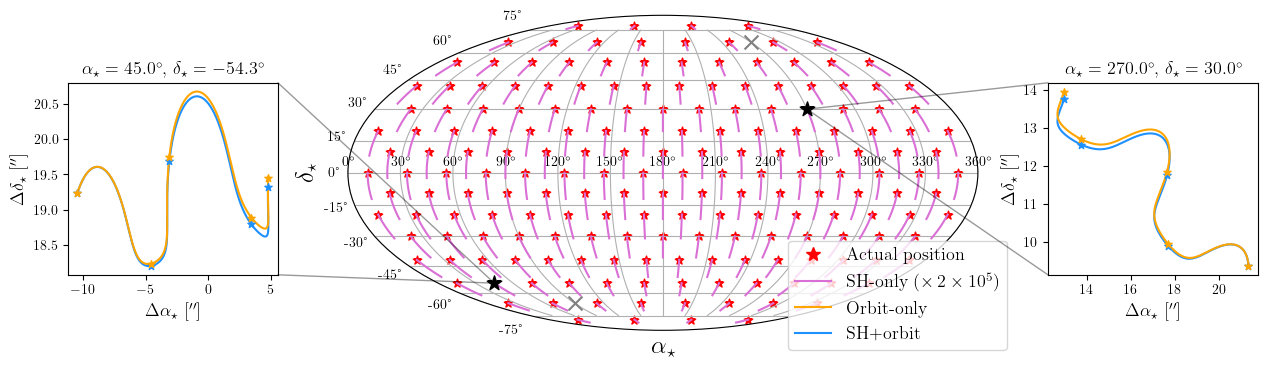

In [12]:
# ============================================================
# Generate uniformly distributed stars using HEALPix
# ============================================================

# HEALPix resolution parameter; nside=4 gives 192 sky pixels
nside = 4
healpix = HEALPix(nside=nside, order="nested", frame=ICRS())
npix = healpix.npix
selected_pixels = np.arange(npix)

# Convert all HEALPix pixels into sky coordinates and extract RA/DEC in radians
star_coords = healpix.healpix_to_skycoord(selected_pixels)
RA = star_coords.ra.rad
DEC = star_coords.dec.rad

# Remove stars very close to RA = 0
mask = np.abs(RA) > 1e-10

RA = RA[mask]
DEC = DEC[mask]


# ============================================================
# Select stars closest to desired positions
# ============================================================

# Desired positions of the two stars used for the detailed trail plots
targets = [(45,-45), (270,30)]
star_ids = []

for ra_deg, dec_deg in targets:

    target_RA = np.radians(ra_deg)
    target_DEC = np.radians(dec_deg)

    # Find the star with the smallest Euclidean distance in RA/DEC
    distance = np.sqrt((RA-target_RA)**2 +(DEC-target_DEC)**2)
    star_ids.append(np.argmin(distance))

star_id_left = star_ids[0]
star_id_right = star_ids[1]


# ============================================================
# Figure layout
# ============================================================

# Create the main figure and three axes:
# one Mollweide sky map and two zoomed-in trail panels
fig = plt.figure(figsize=(14,6))
ax_left = fig.add_axes([0.05,0.28,0.15,0.32])
ax = fig.add_axes([0.25,0.1,0.45,0.7], projection="mollweide")
ax_right = fig.add_axes([0.75,0.28,0.15,0.32])


# ============================================================
# Mollweide: star positions
# ============================================================

# Shift RA by 180° to match the Mollweide plotting convention used here
ra_plot = RA-np.pi

# Plot all HEALPix-based star positions
ax.scatter(ra_plot,DEC,color="red",s=40,marker="*")

# Highlight the two stars selected for the detailed trail panels
for star_id in star_ids:
    ax.scatter(RA[star_id]-np.pi,DEC[star_id],color="black",marker="*",s=120,zorder=3)

# ============================================================
# Mollweide: positions of ecliptic poles
# ============================================================
# Approximate ICRS coordinates of the northern and southern ecliptic poles
ecliptic_poles = [(90,-66.56), (270,66.56)]

for ra_deg, dec_deg in ecliptic_poles:
    ax.scatter(np.radians(ra_deg) - np.pi,np.radians(dec_deg),marker="x",color="gray",s=100,zorder=3)

# ============================================================
# SH-only trails for all stars
# ============================================================

# Artificial magnification used to make the very small SH-induced
# angular displacement visible in the sky map
magnification = 2e5

# Obtain the TESS velocity history for the SH-only case
v_SH_history = v_TESS(True,False)

RA_trails = []
DEC_trails = []

for alpha, delta in zip(RA,DEC):

    # Calculate the stellar trajectory resulting from the SH-induced effect
    alpha_deg, delta_deg = star_trail(alpha, delta, v_SH_history)

    # Convert the resulting trajectory back to radians
    alpha_rad = np.radians(alpha_deg)
    delta_rad = np.radians(delta_deg)

    # Store the initial position as the reference point
    alpha0 = alpha_rad[0]
    delta0 = delta_rad[0]

    # Magnify the displacement relative to the initial position
    alpha_rad = (alpha0+ magnification*(alpha_rad-alpha0))
    delta_rad = (delta0+ magnification*(delta_rad-delta0))

    RA_trails.append(alpha_rad)
    DEC_trails.append(delta_rad)


RA_trails = np.array(RA_trails)
DEC_trails = np.array(DEC_trails)

# Apply the same RA shift as for the stellar positions
ra_trail_plot = RA_trails-np.pi


# Plot the magnified SH-only trajectories.
# The discontinuity check prevents lines from being drawn across
# the RA = ±180° boundary of the Mollweide projection.
for i,(ra_tr,dec_tr) in enumerate(zip(ra_trail_plot,DEC_trails)):
    if len(ra_tr)>1:
        if np.max(np.abs(np.diff(ra_tr))) < np.pi:
            ax.plot(ra_tr, dec_tr, color="orchid")


# ============================================================
# Mollweide axis
# ============================================================

# Define RA tick labels from 0° to 360° in 30° steps
tick_labels = np.arange(0,361,30)

# Corresponding positions in the Mollweide coordinate system
tick_locations = np.radians(np.linspace(-180,180,len(tick_labels)))

ax.set_xticks(tick_locations)
ax.set_xticklabels([f"{x:d}$^\\circ$" for x in tick_labels])

ax.set_xlabel(r"$\alpha_\star$",fontsize=18)
ax.set_ylabel(r"$\delta_\star$",fontsize=18)

ax.grid(True)

# ============================================================
# Function for trail subplots
# ============================================================

def create_trail_subplot(ax_trail, star_id):

    # Initial sky position of the selected star
    alpha_star_0 = RA[star_id]
    delta_star_0 = DEC[star_id]

    # Calculate the trajectory including the SH effect and the TESS orbit
    alpha_star_deg, delta_star_deg = star_trail(alpha_star_0,delta_star_0,v_TESS(True, True))

    # Calculate the trajectory caused by the TESS orbit alone
    alpha_star_deg_orbit, delta_star_deg_orbit = star_trail(alpha_star_0,delta_star_0,v_TESS(False, True))

    # Select five positions along the trajectory for the trail markers
    indices = np.linspace(0,len(alpha_star_deg)-1,5,dtype=int)

    alpha0_deg = np.degrees(alpha_star_0)
    delta0_deg = np.degrees(delta_star_0)


    # Return handles for common legend
    line_SH, = ax_trail.plot([],[],color="dodgerblue",label="SH+orbit")
    line_orbit, = ax_trail.plot([],[],color="orange",label="Orbit-only")

    # Plot the two trajectories in the local trail panels
    x_SH, y_SH = plot_trail(alpha_star_deg,delta_star_deg,alpha0_deg,delta0_deg,color="dodgerblue",label=None,indices=indices,ax=ax_trail)
    x_orbit, y_orbit = plot_trail(alpha_star_deg_orbit,delta_star_deg_orbit,alpha0_deg,delta0_deg,color="orange",label=None,indices=indices,ax=ax_trail)

    # Label the subplot with the initial stellar coordinates
    ax_trail.set_title(rf"$\alpha_\star={alpha0_deg:.1f}^\circ$, "rf"$\delta_\star={delta0_deg:.1f}^\circ$",fontsize=13)

    # Show the angular displacement relative to the initial position
    ax_trail.set_xlabel(r"$\Delta\alpha_\star$ [$^{\prime\prime}$]",fontsize=13)
    ax_trail.set_ylabel(r"$\Delta\delta_\star$ [$^{\prime\prime}$]",fontsize=13)

    # No grid in subplot
    ax_trail.grid(False)

    return line_SH, line_orbit

# Create the two detailed trail panels
line_SH_left, line_orbit_left = create_trail_subplot(ax_left,star_id_left)
line_SH_right, line_orbit_right = create_trail_subplot(ax_right,star_id_right)

# ============================================================
# Connection lines
# ============================================================

def add_connections(ax_trail, star_id, side):
    # Position of the selected star in the Mollweide coordinate system
    star_ra_plot = RA[star_id] - np.pi

    # Get the limits of the corresponding trail subplot
    xlim = ax_trail.get_xlim()
    ylim = ax_trail.get_ylim()

    # Choose the two corners on the side facing the main Mollweide plot
    if side == "left":
        corners = [(xlim[1], ylim[0]),(xlim[1], ylim[1])]
        
    elif side == "right":
        corners = [(xlim[0], ylim[0]),(xlim[0], ylim[1])]

    # Connect the selected star position to both corners of the subplot
    for corner in corners:
        connection = ConnectionPatch(xyA=(star_ra_plot,DEC[star_id]),coordsA=ax.transData,xyB=corner,coordsB=ax_trail.transData,color="black",alpha=0.4,lw=1)
        fig.add_artist(connection)

# Add connections between the selected stars and their trail panels
add_connections(ax_left,star_id_left,"left")
add_connections(ax_right,star_id_right,"right")

# ============================================================
# Common legend in Mollweide plot
# ============================================================

# Define custom legend entries for the different plotted quantities
legend_elements = [
    Line2D([],[],marker="*",color="red",linestyle="None",markersize=10,label="Actual position"),
    Line2D([], [], color="orchid", lw=1.5,label=r"SH-only ($\times$\,$2\times10^5$)"),
    Line2D([],[],color="orange",lw=1.5,label="Orbit-only"),
    Line2D([],[],color="dodgerblue",lw=1.5,label="SH+orbit")
]

ax.legend(handles=legend_elements,fontsize=13,loc="lower right",bbox_to_anchor=(1.06, -0.09))
plt.show()